In [ ]:
import sys
print(sys.executable)


In [ ]:
import sys
!{sys.executable} -m pip install tensorflow


In [ ]:
import keras 
from keras.datasets import mnist 
from keras.models import Sequential 
from keras.layers import Dense 
from tensorflow.keras.optimizers import SGD 
from matplotlib import pyplot as plt

In [6]:
(x_train,y_train),(x_valid,y_valid) = mnist.load_data()
x_train.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


(60000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

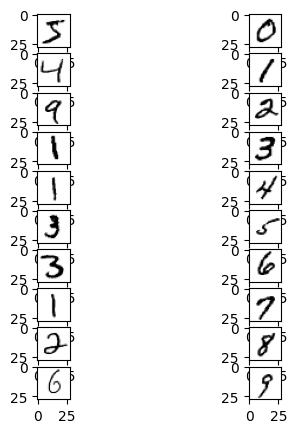

In [9]:
plt.figure(figsize=(5,5)) 
for k in range(20): 
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on') 
plt.show()

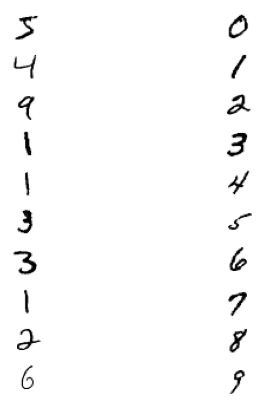

In [10]:
plt.figure(figsize=(5,5)) 
for k in range(20):  
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys')  
    plt.axis('off') 
plt.show()

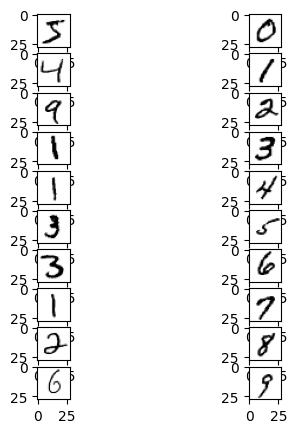

In [11]:

plt.figure(figsize=(5,5)) 
for k in range(20): 
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on') 
plt.show()

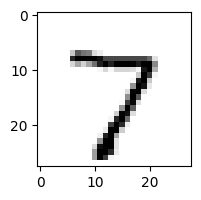

In [14]:
plt.figure(figsize=(2, 2))  # reducing the size no need for exam
plt.imshow(x_valid[0],cmap='Greys')


In [ ]:
y_valid.shapey_valid[0]
x_valid[0]

In [18]:
y_valid[0]

np.uint8(7)

In [19]:
x_train = x_train.reshape(60000,784).astype('float32')
x_valid = x_valid.reshape(10000,784).astype('float32')

In [20]:
x_train/=255 
x_valid/=255

In [ ]:
from keras import utils as np_utils 
n_classes = 10 
y_train = keras.utils.np_utils.to_categorical(y_train,n_classes) 
y_valid= keras.utils.np_utils.to_categorical(y_valid,n_classes)

In [23]:
y_valid[0]

np.uint8(7)

In [ ]:
x_train[0]

In [ ]:
x_valid[3]

In [26]:
y_valid[3]

np.uint8(0)

In [27]:
model = Sequential()

In [32]:
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))    #64 neurons in the hidden layer 784 inputs 

In [33]:
#final layer 
model.add(Dense(10, activation='softmax'))

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
(64*784) #wi xi total weights at input

50176

In [36]:
(64*784)+64

50240

In [37]:
(10*64)+10

650

In [38]:
(10*64)

640

In [45]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=SGD(learning_rate=0.03),
              metrics=['accuracy'])
history= model.fit(x_train,y_train,batch_size=128,epochs=75,verbose=1)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2823 - loss: 2.2423  
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4971 - loss: 2.0103
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6181 - loss: 1.5661  
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7130 - loss: 1.1698
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7751 - loss: 0.9244
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8143 - loss: 0.7666  
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8389 - loss: 0.6561
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.8552 - loss: 0.5773
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8656 - loss: 0.5211
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8732 - loss: 0.4798
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.8803 - loss: 0.4484
Epoch 12/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1

Text(0, 0.5, 'epoch')

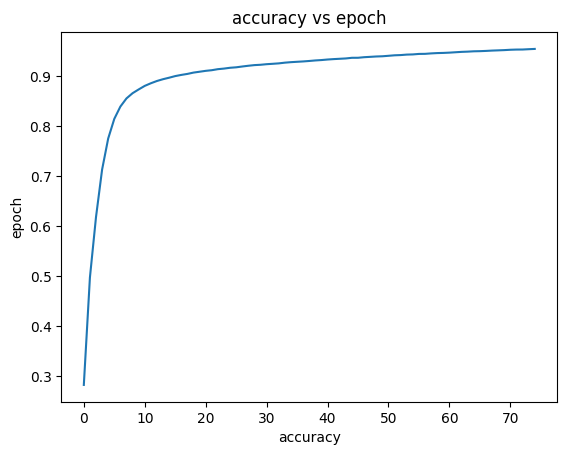

In [47]:
plt.plot(history.history['accuracy']) 
plt.title('accuracy vs epoch')
plt.xlabel('accuracy') 
plt.ylabel('epoch') 


Text(0, 0.5, 'epoch')

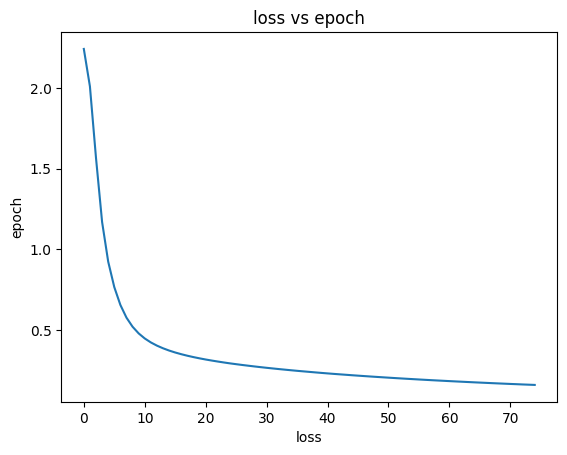

In [48]:
plt.plot(history.history['loss'])
plt.title('loss vs epoch') 
plt.xlabel('loss') 
plt.ylabel('epoch')